In [3]:
import os
import shutil
from sklearn.model_selection import train_test_split

src_folder = "initialDataset"  
dst_folder = "Dataset"           

splits = {'train': 0.7, 'val': 0.1, 'test': 0.2}

count_images = {'train': 0, 'validation': 0, 'test': 0}

for class_name in os.listdir(src_folder):
    class_path = os.path.join(src_folder, class_name)
    if not os.path.isdir(class_path):
        continue
    images = os.listdir(class_path)
    
    
    train_imgs, temp_imgs = train_test_split(images, test_size=splits['val'] + splits['test'], random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=splits['test']/(splits['val'] + splits['test']), random_state=42)
    
    for split, split_imgs in zip(['train','validation','test'], [train_imgs, val_imgs, test_imgs]):
        split_class_folder = os.path.join(dst_folder, split, class_name)
        os.makedirs(split_class_folder, exist_ok=True)
        for img in split_imgs:
            shutil.copy(os.path.join(class_path, img), os.path.join(split_class_folder, img))
        count_images[split] += len(split_imgs)


total_images = sum(count_images.values())
print(f"Train images: {count_images['train']}")
print(f"Validation images: {count_images['validation']}")
print(f"Test images: {count_images['test']}")
print(f"Total images: {total_images}")

Train images: 5590
Validation images: 800
Test images: 1610
Total images: 8000


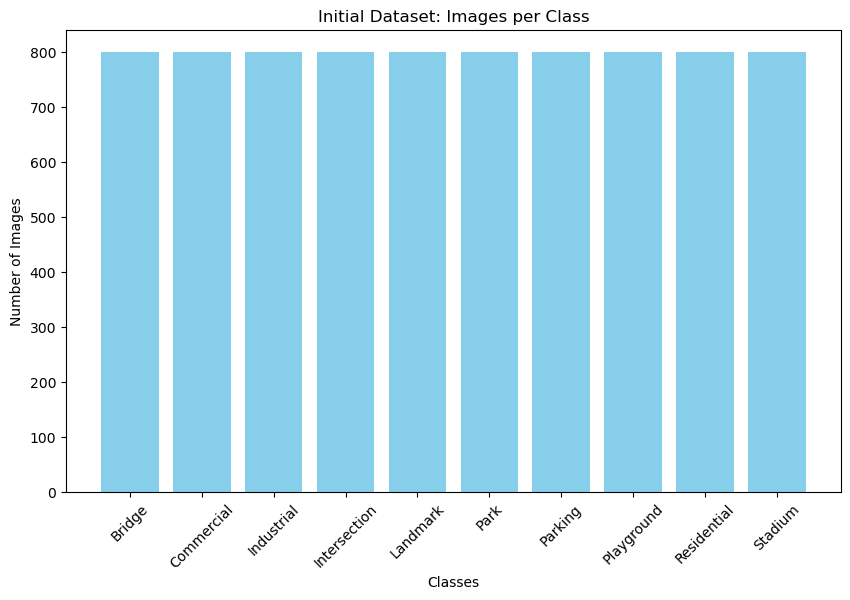

In [6]:
import matplotlib.pyplot as plt

src_folder = "initialDataset"

class_counts = {}

for class_name in os.listdir(src_folder):
    class_path = os.path.join(src_folder, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

# Plot
plt.figure(figsize=(10,6))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Initial Dataset: Images per Class")
plt.xticks(rotation=45)
plt.show()


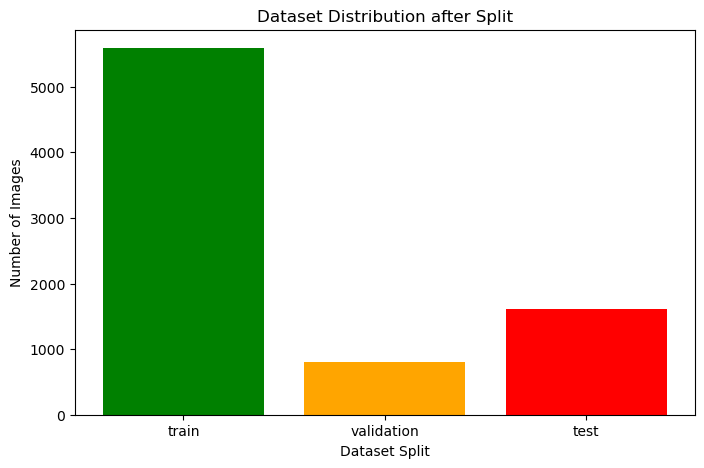

In [3]:
dst_folder = "Dataset"

splits = ['train', 'validation', 'test']
split_counts = {split: 0 for split in splits}

for split in splits:
    split_folder = os.path.join(dst_folder, split)
    for class_name in os.listdir(split_folder):
        class_path = os.path.join(split_folder, class_name)
        if os.path.isdir(class_path):
            split_counts[split] += len(os.listdir(class_path))

# Plot
plt.figure(figsize=(8,5))
plt.bar(split_counts.keys(), split_counts.values(), color=['green','orange','red'])
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution after Split")
plt.show()

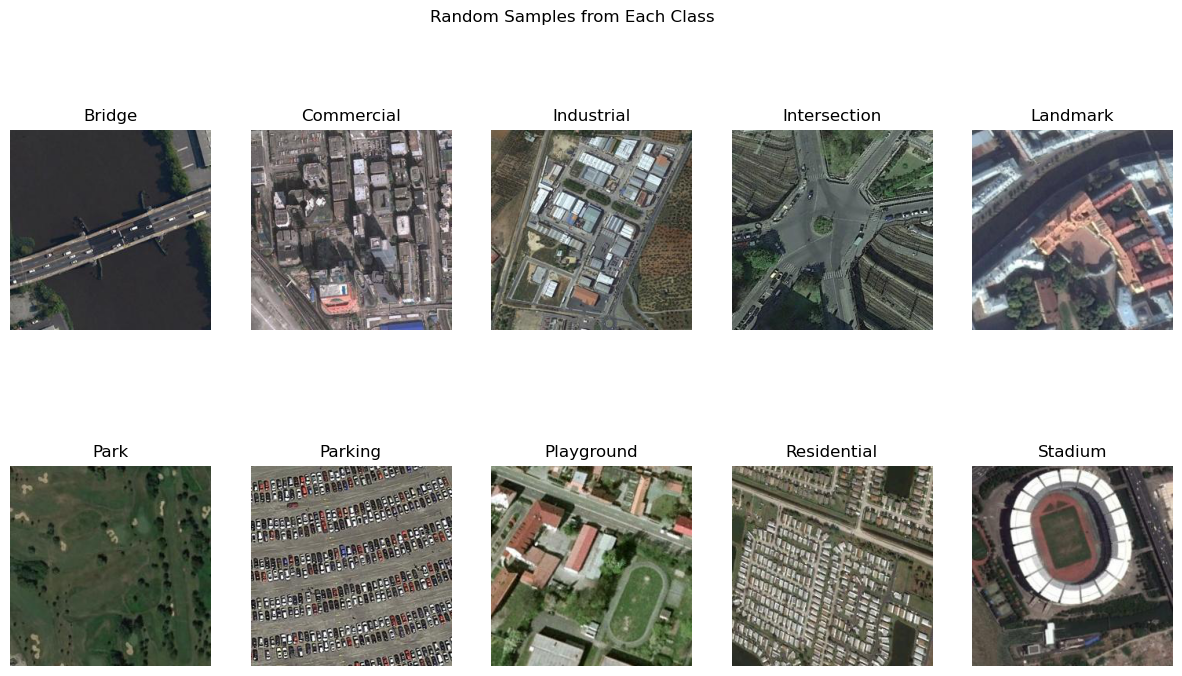

In [4]:
import random
from PIL import Image

src_folder = "initialDataset"
classes = os.listdir(src_folder)

plt.figure(figsize=(15,8))
for i, class_name in enumerate(classes):
    class_path = os.path.join(src_folder, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    img = Image.open(img_path)
    
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.suptitle("Random Samples from Each Class")
plt.show()
